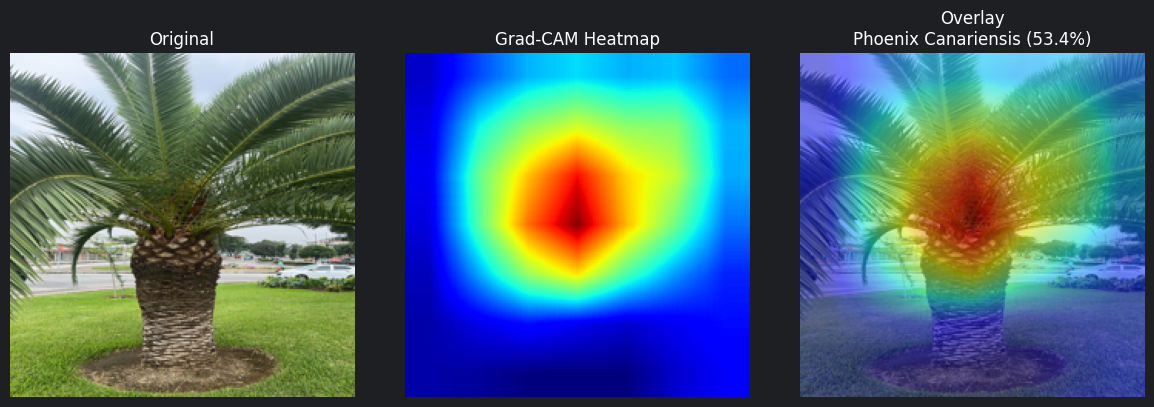

In [5]:
from torchvision import models, transforms
from grad_cam import GradCAM, show_gradcam
import torch.nn as nn

import torch
import os


not_jubaea_directory = "Data/Not_Jubaea"   # Pfad relativ zu deinem aktuellen Arbeitsverzeichnis

classes = ["Jubaea Chilensis"] + sorted(
    d for d in os.listdir(not_jubaea_directory)
    if os.path.isdir(os.path.join(not_jubaea_directory, d))
)
#GPU oder CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

net = models.resnet18(weights=None)
net.fc  = nn.Linear(net.fc.in_features, 11)
net.load_state_dict(torch.load('multiclass_ver1_4.pth', map_location=device))
net = net.to(device)
net.eval()

#Gleiche Transformationen wie beim trainieren
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])



target_layer = net.layer4[-1]
gradcam = GradCAM(net, target_layer)

show_gradcam(
    model = gradcam,
    image_path ="Data/Not_Jubaea/Phoenix Canariensis/ffdsfdsfds.jpg",
    transform = test_transform,
    device = device,
    classes = classes,
)